In [1]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px

In [2]:
df = pd.read_csv("data/papers.csv")
total_papers = len(df)
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Link to Data', 'Data Details', 'Size',
       'Number of Prompts', 'Medical Application', 'Task Type', 'Topic',
       'Note', 'Bias Evaluation Metric', 'Bias Definition', 'Conclusions',
       'Race / Ethnic Bias', 'Language Bias', 'Age Bias', 'Gender Bias',
       'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Geography / Cultural Bias', 'Evaluated LLMs',
       'Reference Standard \n(Human / Model / System / Physician)',
       'Patient Inclusion\n(Yes / No)', 'Has Debiasing',
       'Debias - Focus\n(Data/Train/Inference)', 'Debias-details'],
      dtype='str')

In [3]:
racial_groups_lst = df["Gender Bias"].tolist()

racial_groups_freqs = defaultdict(int)

for s in racial_groups_lst:
    
    if isinstance(s, float):
        racial_groups_freqs[str(s)] += 1
        continue
    
    s = s.strip().lower()
    s = s.replace("_", " ")
    
    if s == "no":
        racial_groups_freqs[s] += 1
        continue
    
    match = re.search(r'\((.*?)\)', s)
    if not match:
        continue
    
    items = match.group(1) 
    races = [race.strip() for race in items.split(',')]
    
    for race in races:
        racial_groups_freqs[race] += 1

racial_groups_freqs


defaultdict(int,
            {'female': 36,
             'male': 36,
             'no': 17,
             'man': 2,
             'non binary': 1,
             'woman': 1,
             'women': 1,
             'transgender female': 1,
             'transgender male': 1,
             'transgender': 1,
             'non conforming': 1})

In [4]:
del racial_groups_freqs["no"]
del racial_groups_freqs["transgender"]

racial_groups_freqs["female"] += racial_groups_freqs["woman"]
racial_groups_freqs["female"] += racial_groups_freqs["women"]
racial_groups_freqs["female"] += racial_groups_freqs["transgender woman"]
racial_groups_freqs["female"] += racial_groups_freqs["transgender female"]

del racial_groups_freqs["woman"]
del racial_groups_freqs["women"]
del racial_groups_freqs["transgender woman"]
del racial_groups_freqs["transgender female"]


racial_groups_freqs["male"] += racial_groups_freqs["man"]
racial_groups_freqs["male"] += racial_groups_freqs["transgender male"]

del racial_groups_freqs["man"]
del racial_groups_freqs["transgender male"]


racial_groups_freqs["non binary"] += racial_groups_freqs["non conforming"]

del racial_groups_freqs["non conforming"]

racial_groups_freqs

defaultdict(int, {'female': 39, 'male': 39, 'non binary': 2})

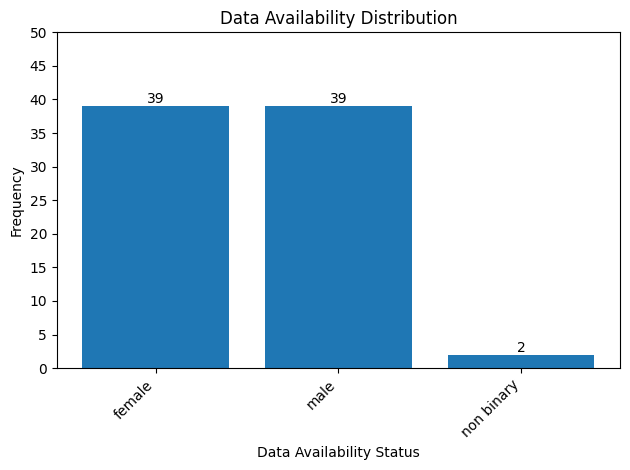

In [5]:
plt.figure()

languages = list(racial_groups_freqs.keys())
counts = list(racial_groups_freqs.values())

bars = plt.bar(languages, counts)

for i, count in enumerate(counts):
    percent = (count / total_papers) * 100
    plt.text(i, count, f"{count}",
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Data Availability Status")
plt.ylabel("Frequency")
plt.ylim((0, 50))
plt.yticks(range(0, 51, 5))
plt.title("Data Availability Distribution")
plt.tight_layout()
plt.show()